## ``Dimensionality Reduction - Loan Default``

##### ``Sandra Ranilla-Cortina``

In [1]:
# Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

plt.style.use('fivethirtyeight')
np.random.seed(777)

import warnings
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = FutureWarning)

#### ``Loan Default Pre-Processed Data``

In [2]:
# Loan Default Pre-Processed data
X_train = pd.read_pickle('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/ML-IA/data/LoanDefault/X_Train_LoanDefault.pkl')
X_test = pd.read_pickle('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/ML-IA/data/LoanDefault/X_Test_LoanDefault.pkl')
Y_train = pd.read_pickle('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/ML-IA/data/LoanDefault/Y_Train_LoanDefault.pkl')
Y_test = pd.read_pickle('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/ML-IA/data/LoanDefault/Y_Test_LoanDefault.pkl')

#### ``Principal Component Analysis (PCA)``

In [3]:
# Dimensionality Reduction - PCA
pca = PCA()
x_train_pca = pca.fit_transform(X_train)
x_train_pca.shape

(191510, 16)

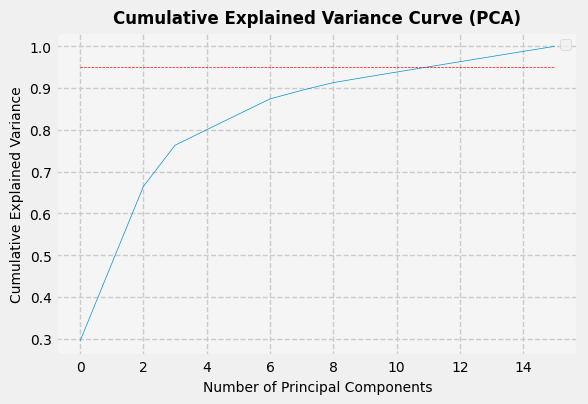

In [4]:
# PCA - Explained Variance Ratio
fig = plt.figure(figsize = (6, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
plt.plot(pca.explained_variance_ratio_.cumsum(), linewidth = 0.5)
plt.plot(np.ones((X_train.shape[1], 1)) * 0.95, 'r--', linewidth = 0.5)
plt.grid(linestyle = '--')
plt.title('Cumulative Explained Variance Curve (PCA)', fontsize = 12, fontweight = 'bold')
plt.ylabel('Cumulative Explained Variance', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
plt.xlabel('Number of Principal Components', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5)
# Number of components to consider (>95% variance explained - aprox. 10)

In [5]:
# Dimensionality Reduction - PCA
pca = PCA(n_components = 10)
X_train_pca = pca.fit_transform(X_train)
X_train_pca = pd.DataFrame(X_train_pca, columns = [f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_train_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,1.995498,0.705278,1.416943,-0.998754,0.161894,0.735380,0.431871,0.490752,-0.507425,0.188201
1,-0.998163,-0.561808,-0.435696,-0.001278,0.071185,0.142757,-0.851484,-0.504627,0.006234,0.339632
2,-0.997810,-0.681793,-1.430184,0.000621,-0.159122,-0.735588,-0.430561,0.490156,-0.501760,0.304889
3,-1.997812,-0.573377,-0.431710,0.997532,0.572257,-0.609687,0.238328,-0.169915,0.003953,-0.069421
4,0.011144,-1.551983,-0.313817,0.989655,0.571545,-0.603916,0.238018,-0.506874,-0.244714,0.319283


In [6]:
# PCA transformation to the test data
X_test_pca = pca.transform(X_test)
X_test_pca = pd.DataFrame(X_test_pca, columns = [f'PC{i+1}' for i in range(X_test_pca.shape[1])])
print(X_train_pca.shape, X_test_pca.shape)

(191510, 10) (63837, 10)


In [7]:
# Save to pickle 
X_train_pca.to_pickle('../../../data/LoanDefault/X_Train_PCA_LoanDefault.pkl')
X_test_pca.to_pickle('../../../data/LoanDefault/X_Test_PCA_LoanDefault.pkl')

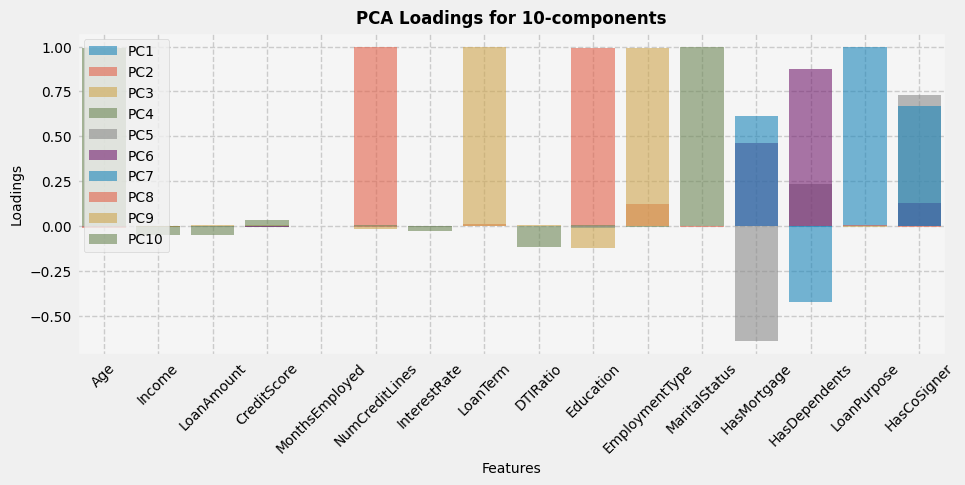

In [8]:
# Loadings (coefficients) for PCA components
loadings = pca.components_
loadings_df = pd.DataFrame(loadings.T, columns = [f'PC{i+1}' for i in range(10)], index = X_train.columns)

# Visualization
fig = plt.figure(figsize = (10, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
for i in range(10):
    sns.barplot(x = loadings_df.index, y = loadings_df[f'PC{i+1}'], label=f'PC{i+1}', alpha=0.6)
plt.grid(linestyle = '--')
plt.title('PCA Loadings for 10-components', fontsize = 12, fontweight = 'bold')
plt.ylabel('Loadings', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
plt.xlabel('Features', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
plt.xticks(rotation = 45)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper left')
legend.get_frame().set_linewidth(0.5)